In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import EARTH_SETTINGS, tomahawk, tomahawk_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import CruiseWaypointGuidance, CruiseGuidanceConfig
from mad.objs.launchers import Launcher, LauncherConfig
from mad.objs.battle_computers import ComputerCommand, BattleComputer, ComputerEvent, ComputerOrder
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

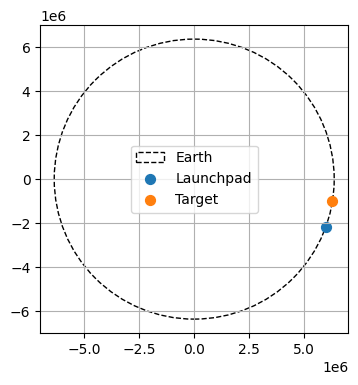

In [8]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1200
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
waypoints = [launchpad, target]
plot_2D_planet_with_points(earth, points = waypoints, display="planet");

In [9]:
tomahawk, tomahawk_guidance

({'name': 'Tomahawk',
  'mass': 1300.0,
  'ref_radius': 0.25,
  'Cd': 0.5,
  'thrust_acc': 50.0,
  'max_range_m': 1600000,
  'yield_kt': 0.0},
 {'max_speed_m_s': 255.21750000000003,
  'altitude_settling_time_s': 60.0,
  'cruise_altitude_m': 50.0})

In [11]:
guidance_config = CruiseGuidanceConfig(waypoints=waypoints, **tomahawk_guidance)
guidance = CruiseWaypointGuidance(planet = earth, target=target, config=guidance_config)
tomahawk_config = CruiseMissileConfig(**tomahawk, guidance=guidance)

tomahawk_missile = CruiseMissile(position=launchpad.position.copy(), config=tomahawk_config)


11:15:39 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (8 dense points), total arc length 1200.0 km.


In [21]:
launcher = Launcher(config=LauncherConfig(projectiles=tomahawk_config, name="Tomahawk Launcher"), 
                    position=launchpad.position.copy())

battle_computer = BattleComputer()
battle_computer.launchers.append(launcher)
battle_computer.position = launchpad.position.copy()
battle_computer.events.append(ComputerEvent(time=5, command=ComputerCommand(order=ComputerOrder.LAUNCH)))

In [22]:
dt = 1.0
max_time = 5_000.0  # enough for 10 000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.collector.ignore_objects = [battle_computer._id, launcher._id]
sim.run(
    planet=earth,
    moving_objs=[battle_computer, launcher],
)

df = sim.results


11:22:52 | INFO     | Simulation   | 0.00s - Starting simulation.
11:22:52 | INFO     | Simulation   | 5.00s - New objects spawned this step: ['Tomahawk']
11:22:55 | INFO     | Missile      | 4403.00s - Tomahawk hit the ground at 1587.10 m from target!
11:22:55 | INFO     | Missile      | 4403.00s - Warhead Tomahawk detonated with yield 0.00 kt.
11:22:55 | INFO     | Simulation   | 5000.00s - Simulation ended. Took 2.13 s of real time.


In [23]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

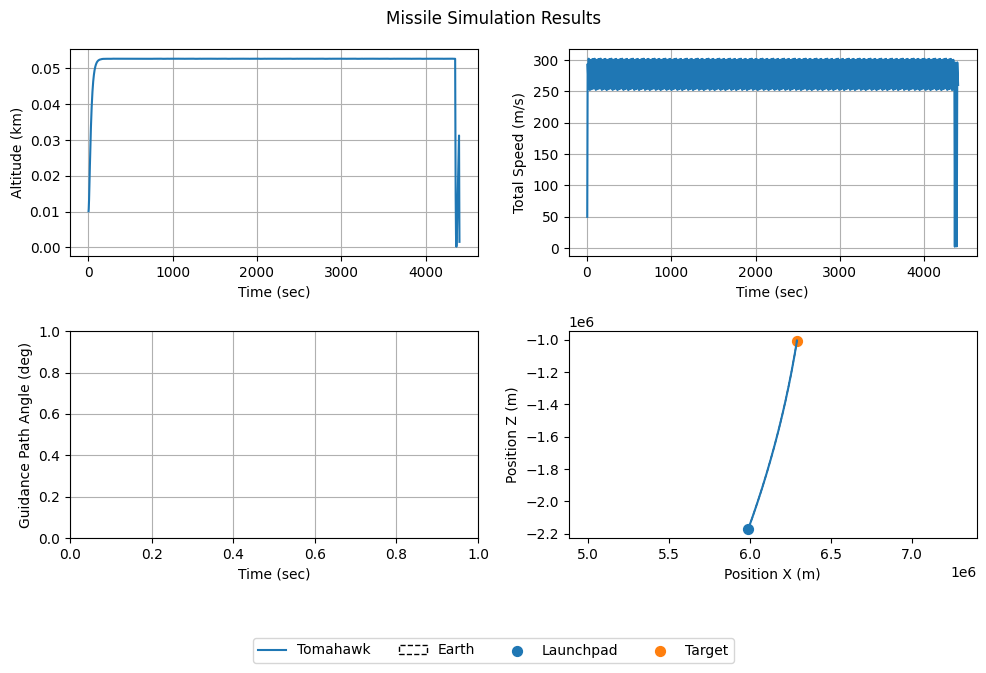

In [24]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)